In [1]:
from spyplotter import Spectrum
%matplotlib widget
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Rotational Broadening

In [2]:
# import raw spectrum
raw_spec = Spectrum.from_powr(filepath='test_data/T33_logg4.0_Mdot-8.5_logL4.72_v1994_vmic8_Z0.1/formal.plot',keywords=['OPT'],dataset=1)

# import broadened spectrum
spec_vrot100_opt = Spectrum.from_file(filename='test_data/test_convolutions/vrot100_opt.dat')
spec_vrot500_opt = Spectrum.from_file(filename='test_data/test_convolutions/vrot500_opt.dat')

spyplotter.spectrum - INFO - No flux unit specified and no signs for y units detected. Thus assuming normalized spectum.
spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


## Plot wrplot results

spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


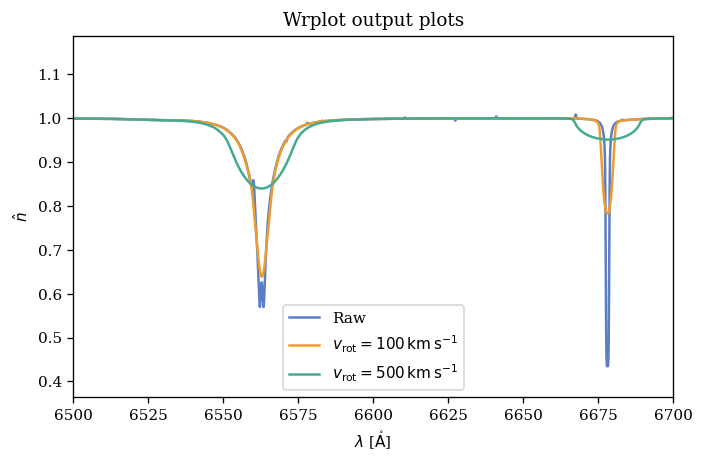

In [3]:
ax = raw_spec.plot(label='Raw',fig_width=6)
ax.set_title('Wrplot output plots')
spec_vrot100_opt.plot(label='$v_{\mathrm{rot}}=100\,\mathrm{km\,s^{-1}}$',ax=ax)
spec_vrot500_opt.plot(label='$v_{\mathrm{rot}}=500\,\mathrm{km\,s^{-1}}$',ax=ax)
ax.set_xlim(6500,6700)
ax.legend()

## Comparison of wrplot with Spyplotter

In [7]:
spec_100 = raw_spec.convolve_rotation(vsini=100,epsilon=0.01,new_spectrum=True)
spec_500 = raw_spec.convolve_rotation(vsini=500,epsilon=0.01,new_spectrum=True)

spyplotter.spec_tools.unit_checks - INFO - No unit for vrad specified. Thus assuming km/s.
spyplotter.spectrum - WARNING - Spectrum is not equally spaced. Interpolating to equally spaced grid.
spyplotter.spec_tools.convolutions - WARNING - WARNING: broadened_flux (137967) is shorter than target length (137968). Padding with last value.
spyplotter.spectrum - INFO - Keeping units of x: Angstrom
spyplotter.spectrum - INFO - Keeping units of y: 
spyplotter.spec_tools.unit_checks - INFO - No unit for vrad specified. Thus assuming km/s.
spyplotter.spectrum - WARNING - Spectrum is not equally spaced. Interpolating to equally spaced grid.
spyplotter.spec_tools.convolutions - WARNING - WARNING: broadened_flux (137966) is shorter than target length (137967). Padding with last value.
spyplotter.spectrum - INFO - Keeping units of x: Angstrom
spyplotter.spectrum - INFO - Keeping units of y: 


n_chunks: 108
n_chunks: 108


spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


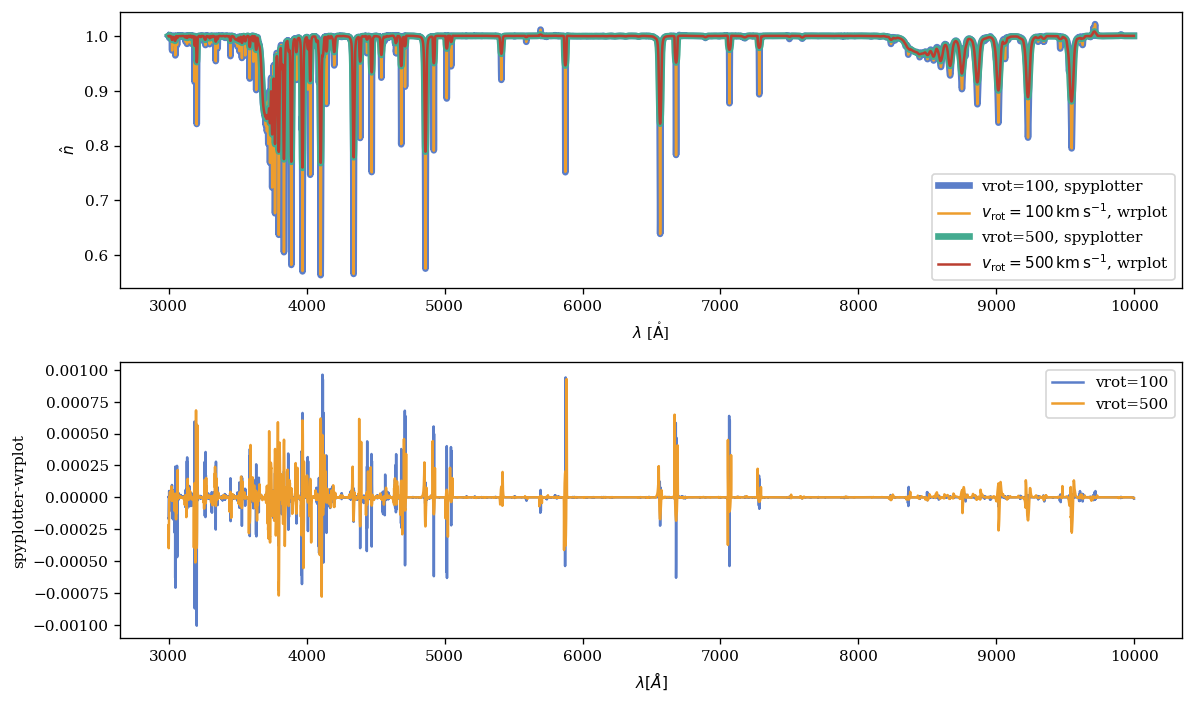

In [16]:
fig, (ax,ax2) = plt.subplots(2,1,figsize=(10,6))


#Show raw spectrum
#raw_spec.plot(label='Raw',ax=ax)

#vrot=100
spec_100.plot(ax=ax,label='vrot=100, spyplotter',lw=4)
spec_vrot100_opt.plot(label='$v_{\mathrm{rot}}=100\,\mathrm{km\,s^{-1}}$, wrplot',ax=ax)

#vrot=500
spec_500.plot(ax=ax,label='vrot=500, spyplotter',lw=4)
spec_vrot500_opt.plot(label='$v_{\mathrm{rot}}=500\,\mathrm{km\,s^{-1}}$, wrplot',ax=ax)
ax.legend()

# Show uncertainties
y_vrot500_interp = interp1d(spec_vrot100_opt.x.value,spec_vrot100_opt.y.value)
ax2.plot(spec_100.x.value,y_vrot500_interp(spec_100.x.value)-spec_100.y.value,label='vrot=100')

y_vrot500_interp = interp1d(spec_vrot500_opt.x.value,spec_vrot500_opt.y.value)
ax2.plot(spec_500.x.value,y_vrot500_interp(spec_500.x.value)-spec_500.y.value,label='vrot=500')
ax2.set_xlabel('$\lambda [\AA]$')
ax2.set_ylabel('spyplotter-wrplot')


ax2.legend()

# Instrumental broadening

In [18]:
# import broadened spectrum
spec_06_opt = Spectrum.from_file(filename='test_data/test_convolutions/conv06_opt.dat')
spec_01_uv = Spectrum.from_file(filename='test_data/test_convolutions/conv01_uv.dat')

spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


## Plot wrplot results

spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


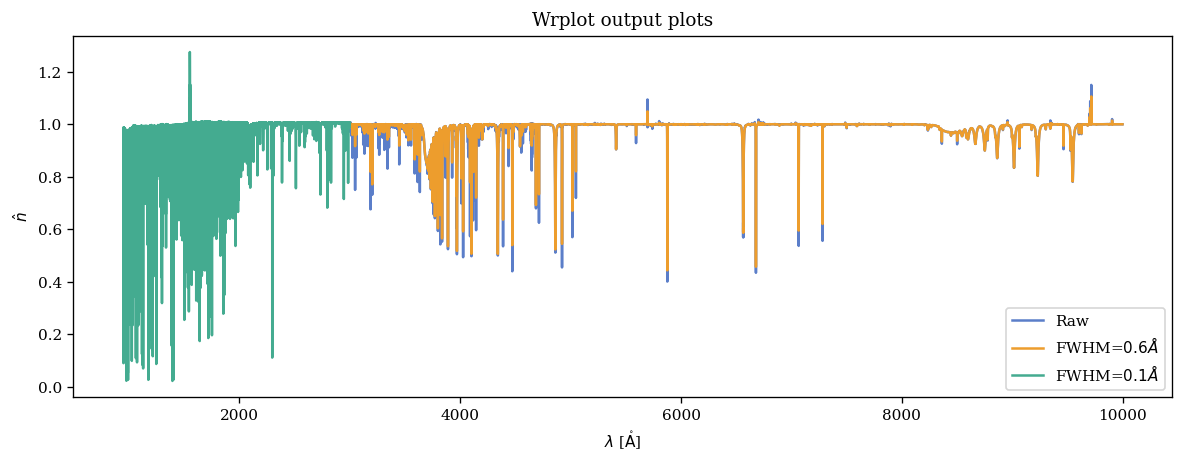

In [20]:
ax = raw_spec.plot(label='Raw',fig_width=10)
ax.set_title('Wrplot output plots')
spec_06_opt.plot(label='FWHM=$0.6 \AA$',ax=ax)
spec_01_uv.plot(label='FWHM=$0.1 \AA$',ax=ax)
#ax.set_xlim(6500,6700)
ax.legend()

## Comparison of wrplot with spyplotter

In [24]:
def gaussian_kernel(x, fwhm):
    """Gaussian kernel over wavelength offset x (same units as fwhm)."""
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    gauss = np.exp(-0.5 * (x / sigma)**2)
    return gauss / np.sum(gauss)

def apply_instrumental_broadening(wavelength, flux, fwhm):
    """
    Apply instrumental broadening using a Gaussian kernel.

    Parameters:
        wavelength (Quantity): Wavelength array with units (e.g., Angstrom)
        flux (Quantity or ndarray): Flux array (same length as wavelength)
        fwhm (float or Quantity): Full width at half maximum of the instrument (same units as wavelength)

    Returns:
        lam_uniform (ndarray): Uniformly spaced wavelength grid
        broadened_flux (ndarray): Flux after instrumental broadening
    """
    # Convert to numpy arrays
    lam = wavelength.to(u.AA).value
    fl = flux

    if isinstance(fwhm, u.Quantity):
        fwhm = fwhm.to(u.AA).value

    # Interpolate onto uniform grid for convolution
    lam_uniform = np.linspace(lam[0], lam[-1], 2 * len(lam))
    flux_uniform = np.interp(lam_uniform, lam, fl)

    # Create Gaussian kernel
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    x = np.linspace(-5 * fwhm, 5 * fwhm, 1001)
    kernel = np.exp(-0.5 * (x / sigma)**2)
    kernel /= np.sum(kernel)

    # Match kernel to wavelength grid spacing
    spacing = lam_uniform[1] - lam_uniform[0]
    interp_grid = np.arange(-5*fwhm, 5*fwhm + spacing, spacing)
    kernel_interp = np.interp(interp_grid, x, kernel, left=0, right=0)
    kernel_interp /= np.sum(kernel_interp)

    # Convolve
    broadened_flux = fftconvolve(flux_uniform, kernel_interp, mode='same')

    return lam_uniform, broadened_flux


spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


In [26]:
FWHM = 0.6
x_uni,broadened_flux_inst = apply_instrumental_broadening(wavelength=xraw*u.AA, flux=yraw, fwhm=FWHM)

fig, (ax,ax2) = plt.subplots(2,1,figsize=(10,5))
ax.plot(x_uni[2:-2], broadened_flux_inst[2:-2],label='own implementation')
raw_spec.plot(ax=ax,label='Raw')
spec_06_opt.plot(label='wrplot, $v_{\mathrm{rot}}=100\,\mathrm{km\,s^{-1}}$',ax=ax)
ax.legend()

y_conv06_interp = interp1d(spec_06_opt.x.value,spec_06_opt.y.value)

ax2.plot(x_uni[300:-300],broadened_flux_inst[300:-300]-y_conv06_interp(x_uni)[300:-300])

NameError: name 'xraw' is not defined

# Macroturbulence

In [65]:
import numpy as np
from scipy.integrate import quad
from scipy.signal import fftconvolve
import astropy.units as u

def rt_macroturbulence_kernel(v, zeta, A_R=0.5, A_T=0.5):
    """
    Compute the radial-tangential macroturbulence broadening kernel.

    Parameters:
        v (ndarray): Velocity array in km/s centered at 0.
        zeta (float): Macroturbulent velocity dispersion in km/s.
        A_R (float): Fractional area with radial motions.
        A_T (float): Fractional area with tangential motions.

    Returns:
        kernel (ndarray): Normalized broadening kernel.
    """
    kernel = np.zeros_like(v)

    for i, vi in enumerate(v):
        # Define the integrand for the given velocity vi
        def integrand(theta):
            cos_theta = np.cos(theta)
            sin_theta = np.sin(theta)
            # Avoid division by zero
            if cos_theta == 0 or sin_theta == 0:
                return 0
            radial = A_R * np.exp(-(vi / (zeta * cos_theta))**2) / (np.sqrt(np.pi) * zeta * cos_theta)
            tangential = A_T * np.exp(-(vi / (zeta * sin_theta))**2) / (np.sqrt(np.pi) * zeta * sin_theta)
            return(radial + tangential)*sin_theta*cos_theta

        # Integrate over theta from 0 to pi/2
        kernel[i], _ = quad(integrand, 0, np.pi / 2)

    # Normalize the kernel
    kernel /= np.trapz(kernel, v)
    return kernel

def apply_rt_macroturbulence(wavelength, flux, zeta):
    """
    Apply radial-tangential macroturbulent broadening to a spectrum.

    Parameters:
        wavelength (Quantity): Wavelength array with units (e.g., Angstrom).
        flux (ndarray): Flux array.
        zeta (float): Macroturbulent velocity dispersion in km/s.

    Returns:
        lam_uniform (ndarray): Uniformly spaced wavelength array.
        broadened_flux (ndarray): Flux after applying macroturbulent broadening.
    """
    # Convert wavelength to Angstroms
    lam = wavelength.to(u.AA).value
    fl = flux
    c_km_s = 299792.458  # Speed of light in km/s

    # Interpolate to a uniform wavelength grid
    lam_uniform = np.linspace(lam[0], lam[-1], 2 * len(lam))
    flux_uniform = np.interp(lam_uniform, lam, fl)

    # Define velocity grid for the kernel
    dv = 10 * zeta  # Extend to ±5 times the dispersion
    v = np.linspace(-dv, dv, 1001)

    # Compute the macroturbulence kernel
    kernel = rt_macroturbulence_kernel(v, zeta)

    # Convert velocity grid to wavelength offsets
    delta_lambda = np.median(lam_uniform) * v / c_km_s

    # Interpolate kernel onto the wavelength grid
    spacing = lam_uniform[1] - lam_uniform[0]
    interp_grid = np.arange(delta_lambda[0], delta_lambda[-1] + spacing, spacing)
    kernel_interp = np.interp(interp_grid, delta_lambda, kernel, left=0, right=0)
    kernel_interp /= np.sum(kernel_interp)

    # Convolve the flux with the kernel
    broadened_flux = fftconvolve(flux_uniform, kernel_interp, mode='same')

    return lam_uniform, broadened_flux


In [66]:
spec_vmac100 = Spectrum.from_file(filename='test_data/test_convolutions/vmac100_opt.dat')

spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


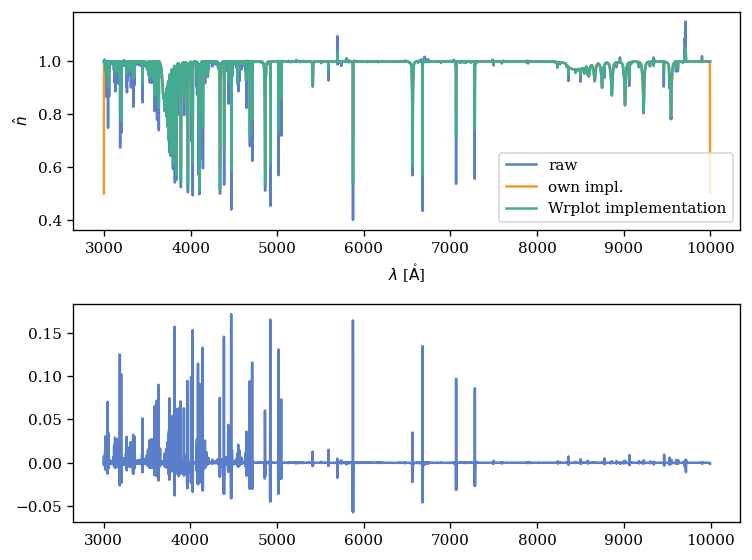

In [67]:
fig, (ax,ax2) = plt.subplots(2,1)

#apply macroturbulent broadening
x_uni,broadened_flux_vmac = apply_rt_macroturbulence(wavelength=xraw*u.AA, flux=yraw, zeta=100)

#plot direct comparison
raw_spec.plot(ax=ax,label='raw')
ax.plot(x_uni,broadened_flux_vmac,label='own impl.')
spec_vmac100.plot(ax=ax,label='Wrplot implementation')
ax.legend()

#plot difference between own and wrplot implementation
y_vmac100_interp = interp1d(spec_vmac100.x.value,spec_vmac100.y.value)
ax2.plot(x_uni[300:-300],broadened_flux_vmac[300:-300]-y_vmac100_interp(x_uni)[300:-300])
